In [1]:
#cloude
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Download and load MNIST into ../data/
# download=True means it fetches from the internet if not already present
transform = transforms.ToTensor()  # Converts PIL images to tensors in [0, 1] range

train_dataset = torchvision.datasets.MNIST(
    root='../data/',       # Saves to your project's /data folder
    train=True,            # Get the training split (60,000 images)
    download=True,         # Download if not already there
    transform=transform    # Apply our ToTensor transform
)

print(f"Dataset size: {len(train_dataset)} images")
print(f"Image tensor shape: {train_dataset[0][0].shape}")  # Should print torch.Size([1, 28, 28])

100.0%
100.0%
100.0%
100.0%

Dataset size: 60000 images
Image tensor shape: torch.Size([1, 28, 28])


In [2]:
def add_gaussian_noise(image_tensor, noise_factor=0.3):
    """
    Corrupts a clean image tensor with Gaussian noise.
    
    Args:
        image_tensor: A torch.Tensor of shape [C, H, W] with values in [0, 1]
        noise_factor:  A float controlling noise intensity.
                       0.1 = subtle, 0.3 = moderate, 0.7+ = heavy corruption
    
    Returns:
        A noisy tensor, clamped to valid range [0, 1]
    """
    # Step A: Generate noise the same shape as the image
    noise = torch.randn_like(image_tensor)
    
    # Step B: Scale the noise down and add it to the clean image
    noisy_image = image_tensor + noise_factor * noise
    
    # Step C: Clip any values that fell outside [0.0, 1.0]
    noisy_image = torch.clamp(noisy_image, 0., 1.)
    
    return noisy_image

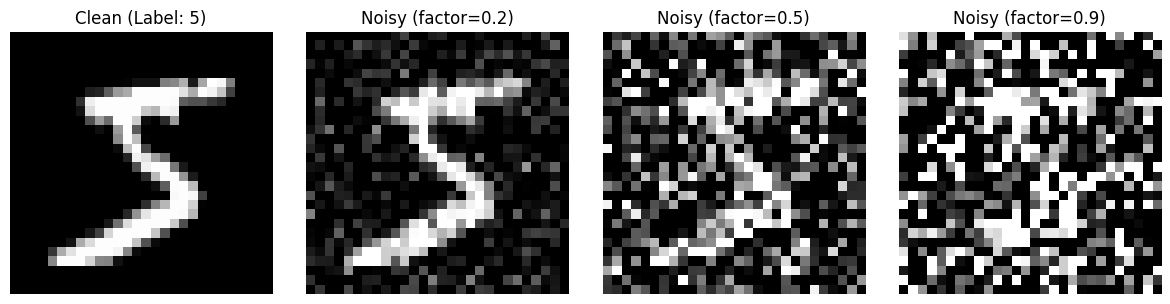

Min pixel value: 0.0000
Max pixel value: 1.0000


In [3]:
# Grab one clean image from the dataset
clean_image, label = train_dataset[0]   # Shape: [1, 28, 28]

# Create noisy versions at different intensities
noisy_light  = add_gaussian_noise(clean_image, noise_factor=0.2)
noisy_medium = add_gaussian_noise(clean_image, noise_factor=0.5)
noisy_heavy  = add_gaussian_noise(clean_image, noise_factor=0.9)

# Plot all four side by side
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(clean_image.squeeze(), cmap='gray')   # .squeeze() removes the channel dim for display
axes[0].set_title(f'Clean (Label: {label})')

axes[1].imshow(noisy_light.squeeze(), cmap='gray')
axes[1].set_title('Noisy (factor=0.2)')

axes[2].imshow(noisy_medium.squeeze(), cmap='gray')
axes[2].set_title('Noisy (factor=0.5)')

axes[3].imshow(noisy_heavy.squeeze(), cmap='gray')
axes[3].set_title('Noisy (factor=0.9)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Sanity check: confirm values are still in valid range
print(f"Min pixel value: {noisy_medium.min():.4f}")   # Should be >= 0.0
print(f"Max pixel value: {noisy_medium.max():.4f}")   # Should be <= 1.0